In [15]:
import gurobipy as grb
import numpy as np
import timeit
import scipy
from sklearn.datasets import make_classification
import sklearn
from ucimlrepo import fetch_ucirepo 
import math
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
import copy
from sklearn.utils import shuffle
from sklearn.preprocessing import OneHotEncoder
from collections import Counter
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler

In [16]:
def generate_n_sample_vec(y_all, perc_test):
    unique_classes, class_counts = np.unique(y_all, return_counts=True)

    # Compute number of test samples per class
    n_sample = np.floor(class_counts * perc_test).astype(int)

    # Ensure at least 1 test sample for each class 
    for i, count in enumerate(class_counts):
        if n_sample[i] == 0 and count > 0:
            n_sample[i] = 1

    # Compute training samples per class 
    n_train_rem = class_counts - n_sample

    
    n_train = {unique_classes[i]: n_train_rem[i] for i in range(len(unique_classes))}
    n_test = {unique_classes[i]: n_sample[i] for i in range(len(unique_classes))}

    print(f" n_train: {n_train}, n_test: {n_test}")
    return n_train, n_test


def l2_normalize_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=float)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)


def class_split_per_client(train_class_counts, perc_class_per_client, G, client_sample_props):
    
    #Get class counts
    n_classes = len(train_class_counts)
    
    if isinstance(perc_class_per_client, np.ndarray):
        print("Using user-defined percentages")
        if perc_class_per_client.shape != (G, n_classes):
            raise ValueError(f"The shape of `perc_class_per_client` should be ({G}, {n_classes})")

        # Normalize to ensure each row sums to 1
        row_sums = perc_class_per_client.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # Prevent division by zero
        perc_class_per_client = perc_class_per_client / row_sums
        
        use_client_sample_props = True
        if client_sample_props is None:
            client_sample_props = [1 / G] * G
        
    # Randomly generated percentages for each client
    elif perc_class_per_client == -1:
        
        if G == 1:
            perc_class_per_client = {0: {class_label: 1.0 for class_label in train_class_counts}}  
        
        else:
            # For G=2
            if G == 2:
                perc_class_per_client = {}
                for class_label in train_class_counts:
                    r = np.random.uniform(low=0.1, high=0.9)
                    perc_class_per_client[0] = perc_class_per_client.get(0, {})
                    perc_class_per_client[0][class_label] = r
                    perc_class_per_client[1] = perc_class_per_client.get(1, {})
                    perc_class_per_client[1][class_label] = 1 - r
                
            else:
                perc_class_per_client = {g: {class_label: 0 for class_label in train_class_counts.keys()} for g in range(G)}
                for class_label in train_class_counts:
                    remaining = 1.0
                    for g in range(G - 1):
                        min_allowed = 0.1
                        max_allowed = remaining - min_allowed * (G - g - 1)
                        r = np.random.uniform(low=min_allowed, high=max_allowed)
                        perc_class_per_client[g] = perc_class_per_client.get(g, {})
                        perc_class_per_client[g][class_label] = r
                        remaining -= r
                    perc_class_per_client[G - 1][class_label] = remaining
                    
    # Uniform distribution across clients
    elif perc_class_per_client == 0:
        perc_class_per_client = {g: {class_label: 1/G for class_label in train_class_counts} for g in range(G)}
        
        use_client_sample_props = False
    else:
        use_client_sample_props = True
        
    print(f"Per class per client:{perc_class_per_client}")
    
    # number of samples each client should receive for each class
    class_split = {g: {} for g in range(G)} 

    for class_label, total_available in train_class_counts.items():  
        print(f"Class {class_label}: Total available samples: {total_available}")
        
        if use_client_sample_props and client_sample_props is not None:
            allocations = [
                int(np.floor(
                    total_available *
                    client_sample_props[g] *
                    perc_class_per_client[g].get(class_label, 0)
                ))
                for g in range(G)
            ]
        else:
            allocations = [
                int(np.floor(
                    total_available *
                    perc_class_per_client[g].get(class_label, 0)
                ))
                for g in range(G)
            ]
        
        total_allocated = sum(allocations)
        discrepancy = total_available - total_allocated
        
        print(f"Class {class_label}: Preliminary allocations: {allocations}")
        print(f"Class {class_label}: Total allocated after floor: {total_allocated}")
        print(f"Class {class_label}: Discrepancy: {discrepancy}")
        
        
        # Distribute the discrepancy
        for g in range(G):
            if discrepancy > 0:
                allocations[g] += 1  
                discrepancy -= 1
                
        if total_available < G:
            # Distribute the available samples evenly among clients
            for g in range(total_available):  
                allocations[g] = 1 

            # Set remaining clients to 0 if there are fewer samples than clients
            for g in range(total_available, G):
                allocations[g] = 0  # No remaining samples to assign
                
        print(f"Class {class_label}: Final allocations per client: {allocations}")   
        
        for g in range(G):
            class_split[g][class_label] = allocations[g]  
         
        
    print(f"Class Split:{class_split}")
        
    return class_split

def change_labels(perc_wrong_y, total_samples, num_classes, y, seed=None):
    y = y.copy()
    rng = np.random.default_rng(seed) 

    n_wrong = int(round(perc_wrong_y * total_samples))
    if n_wrong == 0:
        return y

    idx_wrong = rng.choice(total_samples, size=n_wrong, replace=False)

    for i in idx_wrong:
        old = int(y[i])
        new = rng.integers(0, num_classes - 1)
        if new >= old:
            new += 1
        y[i] = new

    return y


In [30]:
class MultiFederatedPrivateDRSVM_Linearized:

    def __init__(self, param, num_clients, num_classes):
        # DRO + ADMM params
        self.epsilon = float(param["epsilon"])
        self.kappa   = float(param["kappa"])
        self.pnorm   = param["pnorm"]     
        self.rho     = float(param["rho"])
        # Bertsekas penalty parameters
        self.gamma_pen = float(param.get("gamma_pen", 1.0))   
        self.tau_init  = float(param.get("tau_init", 0.0))    
        self.nu      = param.get("nu", None)  

        self.num_clients = int(num_clients)
        self.num_classes = int(num_classes)

        # DP params
        self.dp_on    = bool(param.get("dp_on", False))
        self.eps_dp   = param.get("eps_dp", None)
        self.delta_dp = param.get("delta_dp", None)
        self.cw       = float(param.get("cw", 1.0))
        self.L = float(param.get("L", 1.0))   # loss M-block bound
        self.C = float(param.get("C", 1.0))   # penalty M-block bound

        
        self.feature_dim  = None
        self.Ng_vec       = None
        self.alphag_vec   = None

        self.global_model = None              
        self.mu           = None               

        self.M_prev       = None               
        self.lam_prev     = None            
        self.tau_prev = None
        
        self.clambda = float(param.get("clambda", 1.0))
        self.S_lam = float(param.get("S_lam", 1.0))
        self.V_lam = float(param.get("V_lam", 1.0))

    # DP step sizes 
    def eta_gk(self, g, k):
        Ng = float(self.Ng_vec[g])
        d  = int(self.feature_dim)
        K  = int(self.num_classes)
        dp = d * K

        term = (
            2.0 * (self.L + self.C)**2
            + dp * (8.0 * self.L**2 / (Ng**2)) * (2.0 * np.log(1.25 / self.delta_dp) / (self.eps_dp**2))
        )
        return self.cw / np.sqrt(2.0 * k * term)

    def nu_gk(self, k: int) -> float:

        c_lam = float(self.clambda if self.clambda is not None else 1.0)
        denom = np.sqrt(2.0 * k) * (self.S_lam + self.V_lam)
        if c_lam <= 0:
            raise ValueError("clambda must be > 0")
        if denom <= 0:
            raise ValueError("Need S_lam + V_lam > 0 to define nu_gk")
        return c_lam / denom
    

    def sigma_gk(self, g, k):
        Ng  = float(self.Ng_vec[g])
        eta = self.eta_gk(g, k)
        return ((2.0*np.sqrt(2.0)*self.L) / (Ng*(self.rho + 1.0/eta))
                * np.sqrt(2.0*np.log(1.25/self.delta_dp)) / self.eps_dp)
    
    # Past iteration function evaluation 
    def _cs_hinge_value(self, scores, y):

        tmp = scores.copy()
        tmp[y] = -np.inf
        c_star = int(np.argmax(tmp))
        H = 1.0 + scores[c_star] - scores[y]
        return float(max(0.0, H))


    def phi_value(self, M):

        K, d = M.shape
        best_val = -np.inf

        for i in range(K):
            for j in range(K):
                if i == j:
                    continue
                u = M[i, :] - M[j, :]

                if self.pnorm == 1:
                    val = np.sum(np.abs(u))              # ||u||_1
                elif self.pnorm == 2:
                    val = np.linalg.norm(u, 2)           # ||u||_2
                elif self.pnorm == np.inf or self.pnorm == float('Inf'):
                    val = np.max(np.abs(u))              # ||u||_inf
                else:
                    raise ValueError("Use pnorm=1, 2, or np.inf.")

                if val > best_val:
                    best_val = val

        return float(best_val)


    def bertsekas_penalty_value(self, M, lam, gamma_pen, tau):

        phi = self.phi_value(M)
        r = float(tau + gamma_pen * (phi - lam))
        return (max(0.0, r)**2 - float(tau)**2) / (2.0 * float(gamma_pen))


    def f_value(self, M, lam, x_train, y_train, gamma_pen, tau):

        K = self.num_classes
        N, d = x_train.shape
        if N == 0:
            return 0.0

        y_train = y_train.astype(int)
        total = 0.0

        for n in range(N):
            x = x_train[n]
            y_true = int(y_train[n])
            scores = M @ x

            A = self._cs_hinge_value(scores, y_true)

            B_best = -np.inf
            for y in range(K):
                if y == y_true:
                    continue
                loss_y = self._cs_hinge_value(scores, y)
                val = loss_y - self.kappa * lam
                if val > B_best:
                    B_best = val

            total += max(A, B_best)

        loss_part = total / float(N)
        pen_part = self.bertsekas_penalty_value(M, lam, gamma_pen, tau)

        return float(loss_part + pen_part)

    
    # compute largest dual between any two class weights
    def phi_and_subgrad(self, M):

        K, d = M.shape
        best_val = -np.inf
        best_i = best_j = None
        best_u = None

        for i in range(K):
            for j in range(K):
                if i == j:
                    continue

                u = M[i, :] - M[j, :]

                if self.pnorm == 1:
                    val = np.sum(np.abs(u))
                elif self.pnorm == 2:
                    val = np.linalg.norm(u, 2)
                elif self.pnorm == np.inf or self.pnorm == float("Inf"):
                    val = np.max(np.abs(u))
                else:
                    raise ValueError("Use pnorm=1, 2, or np.inf.")

                if val > best_val:
                    best_val = val
                    best_i, best_j = i, j
                    best_u = u.copy()

        phi = float(best_val)
        Gphi = np.zeros_like(M)

        if best_u is None:
            return 0.0, Gphi

        if self.pnorm == 1:
            
            g = np.sign(best_u)   

        elif self.pnorm == 2:
            norm_u = np.linalg.norm(best_u, 2)
            if norm_u > 1e-12:
                g = best_u / norm_u
            else:
                g = np.zeros(d)

        else:  
            p_star = int(np.argmax(np.abs(best_u)))
            g = np.zeros(d)
            if abs(best_u[p_star]) > 1e-12:
                g[p_star] = np.sign(best_u[p_star])
            else:
                g[p_star] = 0.0

        Gphi[best_i, :] += g
        Gphi[best_j, :] -= g

        return phi, Gphi

    # subgradient at previous iterate 
    def _cs_hinge_and_grad(self, scores, x, y):

        K = scores.shape[0]
        # best competitor class c* != y
        tmp = scores.copy()
        tmp[y] = -np.inf
        c_star = int(np.argmax(tmp))

        H = 1.0 + scores[c_star] - scores[y]
        if H <= 0.0:
            return 0.0, None  # inactive

        # subgrad wrt M: add +x to row c*, -x to row y
        return float(H), (c_star, y)  # we’ll apply x outside


    def subgrad_f(self, M_prev, lam_prev, x_train, y_train, gamma_pen, tau):

        K = self.num_classes
        N, d = x_train.shape
        if N == 0:
            return np.zeros((K, d), dtype=float), 0.0

        y_train = y_train.astype(int)

        G_M = np.zeros((K, d), dtype=float)
        g_lam = 0.0

        # loss part
        for n in range(N):
            x = x_train[n]
            y_true = int(y_train[n])

            scores = M_prev @ x  

            
            A_loss, A_pair = self._cs_hinge_and_grad(scores, x, y_true)

            
            B_best = -np.inf
            B_loss = 0.0
            B_pair = None

            for y in range(K):
                if y == y_true:
                    continue
                loss_y, pair_y = self._cs_hinge_and_grad(scores, x, y)
                val = loss_y - self.kappa * lam_prev
                if val > B_best:
                    B_best = val
                    B_loss = loss_y
                    B_pair = pair_y

            # outer max
            if A_loss >= B_best:
                # choose A branch
                if A_pair is not None:
                    c_star, y = A_pair
                    G_M[c_star, :] += x
                    G_M[y,      :] -= x
                
            else:
                # choose B branch
                if B_pair is not None:
                    c_star, y = B_pair
                    G_M[c_star, :] += x
                    G_M[y,      :] -= x
                # lambda derivative from (-kappa*lambda)
                g_lam += -self.kappa

        # average loss subgrad 
        G_M /= float(N)
        g_lam /= float(N)

        #  Bertsekas penalty part on (phi(M)-lambda) 
        phi_val, G_phi = self.phi_and_subgrad(M_prev)
        r = float(tau + gamma_pen * (phi_val - lam_prev))
        if r > 0.0:
            G_M += r * G_phi
            g_lam += -r
        #returns subgradient wrt M and wrt lambda    
        return G_M, g_lam


    #  linearized local QP solve 
    def local_update_linearized(self, client_id, x_train, y_train, M_global, mu, k):

        N, d = x_train.shape
        K = self.num_classes
        

        M_prev  = self.M_prev[client_id]
        lam_prev = float(self.lam_prev[client_id])

        if self.dp_on:
            eta = self.eta_gk(client_id, k)
        else:
            eta = self.cw / np.sqrt(2.0 * max(k, 1))

        if self.nu is None:
            nu = self.nu_gk(k)
        else:
            nu = float(self.nu)

        tau = float(self.tau_prev[client_id])
        gamma_pen = float(self.gamma_pen)

        G_M, g_lam = self.subgrad_f(
            M_prev, lam_prev, x_train, y_train,
            gamma_pen=gamma_pen, tau=tau
        )

        f_prev = self.f_value(
            M_prev, lam_prev, x_train, y_train,
            gamma_pen=gamma_pen, tau=tau
        )

        model = grb.Model(f"LIN_DRSVM_Client_{client_id}")
        model.setParam("OutputFlag", False)

        var_lambda = model.addVar(vtype=grb.GRB.CONTINUOUS, lb=0.0)
        var_M = {(c, j): model.addVar(vtype=grb.GRB.CONTINUOUS, lb=-grb.GRB.INFINITY)
                 for c in range(K) for j in range(d)}

        model.update()

        # Objective
        obj = 0.0

        # lambda * epsilon
        obj += var_lambda * self.epsilon

        # <G_M, M - M_prev>
        obj += grb.quicksum(
            float(G_M[c, j]) * (var_M[(c, j)] - float(M_prev[c, j]))
            for c in range(K) for j in range(d)
        )

        # g_lam * (lambda - lam_prev)
        obj += float(g_lam) * (var_lambda - float(lam_prev))

        # rho/2 ||M - M_global + mu||^2
        obj += (self.rho / 2.0) * grb.quicksum(
            (var_M[(c, j)] - float(M_global[c, j]) + float(mu[c, j]))
            * (var_M[(c, j)] - float(M_global[c, j]) + float(mu[c, j]))
            for c in range(K) for j in range(d)
        )

        # 1/(2 eta) ||M - M_prev||^2
        obj += (1.0 / (2.0 * eta)) * grb.quicksum(
            (var_M[(c, j)] - float(M_prev[c, j])) * (var_M[(c, j)] - float(M_prev[c, j]))
            for c in range(K) for j in range(d)
        )

        # 1/(2 nu) (lambda - lam_prev)^2
        obj += (1.0 / (2.0 * nu)) * (var_lambda - float(lam_prev)) * (var_lambda - float(lam_prev))
        

        model.setObjective(obj, grb.GRB.MINIMIZE)
        model.optimize()

        status = model.Status
        print(f"[client {client_id}, round {k}] status = {status}")

        if status != grb.GRB.OPTIMAL:
            print(f"[client {client_id}, round {k}] non-optimal solve")
            print(f"  eta = {eta}")
            print(f"  nu = {nu}")
            print(f"  tau = {tau}")
            print(f"  gamma_pen = {gamma_pen}")
            print(f"  lam_prev = {lam_prev}")
            print(f"  g_lam = {g_lam}")
            print(f"  f_prev = {f_prev}")
            print(f"  any NaN in G_M? {np.isnan(G_M).any()}")
            print(f"  any Inf in G_M? {np.isinf(G_M).any()}")
            print(f"  any NaN in M_prev? {np.isnan(M_prev).any()}")
            print(f"  any Inf in M_prev? {np.isinf(M_prev).any()}")

            return {
                "w": M_prev.copy(),
                "lambda": float(lam_prev),
                "objective_qp": np.nan,
                "f_prev": float(f_prev),
                "Lhat": np.nan,
                "status": int(status),
                "eta_used": float(eta),
            }

        obj_val = float(model.ObjVal)
        Lhat = float(f_prev + obj_val)

        w_opt = np.zeros((K, d), dtype=float)
        for c in range(K):
            for j in range(d):
                w_opt[c, j] = var_M[(c, j)].X

        return {
            "w": w_opt,
            "lambda": float(var_lambda.X),
            "objective_qp": obj_val,
            "f_prev": float(f_prev),
            "Lhat": Lhat,
            "status": int(status),
            "eta_used": float(eta),
        }

    def train(self, client_sets, num_rounds, return_history=False):
        
        self.Ng_vec = np.array(
            [len(client_sets[f"x{i}"]) for i in range(self.num_clients)],
            dtype=float
        )
        self.alphag_vec = self.Ng_vec / np.sum(self.Ng_vec)

        
        if self.feature_dim is None:
            self.feature_dim = int(client_sets["x0"].shape[1])

        K, d = self.num_classes, self.feature_dim

        if self.global_model is None:
            self.global_model = np.zeros((K, d), dtype=float)
        if self.mu is None:
            self.mu = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)]

        if self.M_prev is None:
            self.M_prev = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)]
        if self.lam_prev is None:
            self.lam_prev = [0.0 for _ in range(self.num_clients)]
        if self.tau_prev is None:
            self.tau_prev = [float(self.tau_init) for _ in range(self.num_clients)]

        if self.dp_on:
            if self.L is None:
                self.L = 1.0
            if self.eps_dp is None or self.delta_dp is None:
                raise ValueError("dp_on=True requires eps_dp and delta_dp")
            if self.eps_dp <= 0:
                raise ValueError("eps_dp must be > 0")
            if not (0 < self.delta_dp < 1):
                raise ValueError("delta_dp must be in (0,1)")

        prev_global = self.global_model.copy()

        # running sums for ergodic metrics evaluated at averaged iterates
        sum_M_clients = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)]
        sum_lam_clients = [0.0 for _ in range(self.num_clients)]
        sum_tau_clients = [0.0 for _ in range(self.num_clients)]
        sum_M_global = np.zeros((K, d), dtype=float)

        # running sums for ergodic averages of the scalar metrics
        cum_combined = 0.0
        cum_primal = 0.0
        cum_consensus = 0.0

        history = {
            "round": [],
            "primal_obj": [],
            "consensus_clean": [],
            "combined_metric": [],
            "mean_abs_lambda": [],
            "global_diff": [],
            "mean_Lhat": [],
            "mean_objective_qp": [],
            "mean_f_prev": [],
            "combined_metric_ergodic": [],
            "primal_obj_ergodic": [],
            "consensus_clean_ergodic": [],
            "primal_obj_ergodic_iterates": [],
            "consensus_clean_ergodic_iterates": [],
            "combined_metric_ergodic_iterates": [],
        }

        for k in range(1, int(num_rounds) + 1):
            local_models = []

            for i in range(self.num_clients):
                x_i = client_sets[f"x{i}"]
                y_i = client_sets[f"y{i}"].astype(int)

                out = self.local_update_linearized(
                    client_id=i,
                    x_train=x_i,
                    y_train=y_i,
                    M_global=self.global_model,
                    mu=self.mu[i],
                    k=k
                )

                w_clean = out["w"]
                lam_clean = float(out["lambda"])

                self.M_prev[i] = w_clean.copy()
                self.lam_prev[i] = lam_clean

                phi_val, _ = self.phi_and_subgrad(w_clean)
                gamma_pen = float(self.gamma_pen)
                self.tau_prev[i] = max(
                    0.0,
                    self.tau_prev[i] + gamma_pen * (phi_val - lam_clean)
                )

                if self.dp_on:
                    sigma = self.sigma_gk(i, k)
                    noise = np.random.normal(0.0, sigma, size=w_clean.shape)
                    w_send = w_clean + noise
                else:
                    w_send = w_clean

                out["w_clean"] = w_clean
                out["w_send"] = w_send
                out["tau_clean"] = float(self.tau_prev[i])
                local_models.append(out)

            # server aggregation
            local_updates = np.array([
                local_models[i]["w_send"] + self.mu[i]
                for i in range(self.num_clients)
            ])
            weighted = self.alphag_vec[:, None, None] * local_updates
            self.global_model = np.sum(weighted, axis=0)

            for i in range(self.num_clients):
                self.mu[i] += local_models[i]["w_send"] - self.global_model

            #  current-iterate metrics 
            primal_obj_k = 0.0
            consensus_clean_k = 0.0

            for i in range(self.num_clients):
                x_i = client_sets[f"x{i}"]
                y_i = client_sets[f"y{i}"].astype(int)

                M_i = local_models[i]["w_clean"]
                lam_i = float(local_models[i]["lambda"])
                tau_i = float(self.tau_prev[i])

                h_i = self.epsilon * lam_i + self.f_value(
                    M_i, lam_i, x_i, y_i,
                    gamma_pen=float(self.gamma_pen),
                    tau=tau_i
                )

                primal_obj_k += float(self.alphag_vec[i]) * float(h_i)
                consensus_clean_k += float(self.alphag_vec[i]) * np.linalg.norm(
                    M_i - self.global_model, ord="fro"
                )

            combined_k = primal_obj_k + beta * consensus_clean_k
            diff = np.linalg.norm(self.global_model - prev_global, ord="fro")

            # ergodic average of scalar metrics 
            cum_primal += primal_obj_k
            cum_consensus += consensus_clean_k
            cum_combined += combined_k

            primal_obj_ergodic_k = cum_primal / k
            consensus_clean_ergodic_k = cum_consensus / k
            combined_metric_ergodic_k = cum_combined / k

            # accumulate iterates for ergodic-iterate metric 
            for i in range(self.num_clients):
                sum_M_clients[i] += local_models[i]["w_clean"]
                sum_lam_clients[i] += float(local_models[i]["lambda"])
                sum_tau_clients[i] += float(local_models[i]["tau_clean"])

            sum_M_global += self.global_model

            #  ergodic metric evaluated at averaged iterates 
            M_global_bar = sum_M_global / float(k)

            primal_obj_erg_iter_k = 0.0
            consensus_erg_iter_k = 0.0

            for i in range(self.num_clients):
                x_i = client_sets[f"x{i}"]
                y_i = client_sets[f"y{i}"].astype(int)

                M_i_bar = sum_M_clients[i] / float(k)
                lam_i_bar = sum_lam_clients[i] / float(k)
                tau_i_bar = sum_tau_clients[i] / float(k)

                h_i_bar = self.epsilon * lam_i_bar + self.f_value(
                    M_i_bar, lam_i_bar, x_i, y_i,
                    gamma_pen=float(self.gamma_pen),
                    tau=tau_i_bar
                )

                primal_obj_erg_iter_k += float(self.alphag_vec[i]) * float(h_i_bar)
                consensus_erg_iter_k += float(self.alphag_vec[i]) * np.linalg.norm(
                    M_i_bar - M_global_bar, ord="fro"
                )

            combined_erg_iter_k = primal_obj_erg_iter_k + beta * consensus_erg_iter_k

            #  store history 
            history["round"].append(k)
            history["primal_obj"].append(float(primal_obj_k))
            history["consensus_clean"].append(float(consensus_clean_k))
            history["combined_metric"].append(float(combined_k))
            history["mean_abs_lambda"].append(float(np.mean(np.abs(self.lam_prev))))
            history["global_diff"].append(float(diff))

            history["mean_Lhat"].append(float(np.nanmean([m["Lhat"] for m in local_models])))
            history["mean_objective_qp"].append(float(np.nanmean([m["objective_qp"] for m in local_models])))
            history["mean_f_prev"].append(float(np.nanmean([m["f_prev"] for m in local_models])))

            history["primal_obj_ergodic"].append(float(primal_obj_ergodic_k))
            history["consensus_clean_ergodic"].append(float(consensus_clean_ergodic_k))
            history["combined_metric_ergodic"].append(float(combined_metric_ergodic_k))

            history["primal_obj_ergodic_iterates"].append(float(primal_obj_erg_iter_k))
            history["consensus_clean_ergodic_iterates"].append(float(consensus_erg_iter_k))
            history["combined_metric_ergodic_iterates"].append(float(combined_erg_iter_k))

            print(f"[LIN-DRO] round {k}: ||w^k - w^(k-1)||_F = {diff:.4e}")
            prev_global = self.global_model.copy()

        if return_history:
            return self.global_model, history
        return self.global_model

    # ---------------- prediction ----------------
    def test(self, test_set):
        x_test = test_set["x"]
        scores = x_test @ self.global_model.T
        y_hat = np.argmax(scores, axis=1)
        
        
        counts = np.bincount(y_hat, minlength=self.num_classes)
        print("Pred counts:", counts)

        N = x_test.shape[0]
        K = self.num_classes
        y_pred = np.zeros((N, K), dtype=int)
        y_pred[np.arange(N), y_hat] = 1
        return y_pred

In [31]:
def run_delta_convergence_experiment(delta_list, eps_dp, seeds, num_rounds, train_fn_for_delta):
    results = {
        "delta": [],

        "primal_obj_mean": [],
        "primal_obj_std": [],

        "consensus_mean": [],
        "consensus_std": [],

        "combined_mean": [],
        "combined_std": [],
    }

    for delta in delta_list:
        all_obj = []
        all_cons = []
        all_combined = []

        for seed in seeds:
            hist = train_fn_for_delta(delta, eps_dp, seed)

            obj_curve = np.array(hist["primal_obj_ergodic_iterates"], dtype=float)
            cons_curve = np.array(hist["consensus_clean_ergodic_iterates"], dtype=float)
            combined_curve = np.array(hist["combined_metric_ergodic_iterates"], dtype=float)

            if len(obj_curve) != num_rounds:
                raise ValueError(
                    f"Seed {seed}, delta {delta}: primal_obj length {len(obj_curve)} != num_rounds {num_rounds}"
                )
            if len(cons_curve) != num_rounds:
                raise ValueError(
                    f"Seed {seed}, delta {delta}: consensus_clean length {len(cons_curve)} != num_rounds {num_rounds}"
                )
            if len(combined_curve) != num_rounds:
                raise ValueError(
                    f"Seed {seed}, delta {delta}: combined_metric length {len(combined_curve)} != num_rounds {num_rounds}"
                )

            all_obj.append(obj_curve)
            all_cons.append(cons_curve)
            all_combined.append(combined_curve)

        all_obj = np.stack(all_obj, axis=0)
        all_cons = np.stack(all_cons, axis=0)
        all_combined = np.stack(all_combined, axis=0)

        obj_mean = np.mean(all_obj, axis=0)
        obj_std = np.std(all_obj, axis=0, ddof=1) if len(seeds) > 1 else np.zeros(num_rounds)

        cons_mean = np.mean(all_cons, axis=0)
        cons_std = np.std(all_cons, axis=0, ddof=1) if len(seeds) > 1 else np.zeros(num_rounds)

        combined_mean = np.mean(all_combined, axis=0)
        combined_std = np.std(all_combined, axis=0, ddof=1) if len(seeds) > 1 else np.zeros(num_rounds)

        results["delta"].append(float(delta))
        results["primal_obj_mean"].append(obj_mean)
        results["primal_obj_std"].append(obj_std)
        results["consensus_mean"].append(cons_mean)
        results["consensus_std"].append(cons_std)
        results["combined_mean"].append(combined_mean)
        results["combined_std"].append(combined_std)

        print(
            f"delta={delta}: "
            f"final primal obj={obj_mean[-1]:.6e}, "
            f"final consensus={cons_mean[-1]:.6e}, "
            f"final combined={combined_mean[-1]:.6e}"
        )

    return results

In [32]:
def epsilon_bar_from_eps_delta(eps, delta, t=50):
    return float(eps * np.sqrt((t * np.log(1.0 / delta)) / np.log(1.25 / delta)))


def plot_delta_convergence(
    results,
    metric_key,
    epsilon,
    title,
    ylabel,
    skip_first=True,
    y_limits=(1.00, 1.40),
    show_std=False,
):
    fig, ax = plt.subplots(figsize=(6.2, 4.4))

    # muted palette
    colors = [
        "#4C78A8",  # muted blue
        "#C44E52",  # muted red
        "#55A868",  # muted green
        "#8172B2",  # muted purple
        "#CCB974",  # muted gold
        "#64B5CD",  # muted cyan
    ]

    T = len(results[metric_key][0])
    rounds = np.arange(1, T + 1)
    start = 1 if skip_first else 0

    for idx, delta in enumerate(results["delta"]):
        m = np.asarray(results[metric_key][idx], dtype=float)
        r = rounds[start:]
        m_full = m[start:]

        eps_bar = epsilon_bar_from_eps_delta(epsilon, delta, t=50)
        label = rf"$\delta={delta:.0e},\ \bar{{\epsilon}}={eps_bar:.3f}$"

        color = colors[idx % len(colors)]

        ax.plot(
            r,
            m_full,
            linewidth=1.6,
            alpha=0.95,
            color=color,
            label=label,
        )

        if show_std:
            std_key = metric_key.replace("_mean", "_std")
            if std_key in results:
                s = np.asarray(results[std_key][idx], dtype=float)[start:]
                ax.fill_between(r, m_full - s, m_full + s, color=color, alpha=0.08)

    ax.set_ylim(y_limits[0], y_limits[1])

    ax.set_xlabel("Training round (k)", fontsize=16, fontfamily="serif")
    ax.set_ylabel(ylabel, fontsize=16, fontfamily="serif")
    ax.set_title(title, fontsize=14, fontfamily="serif")

    ax.grid(True, which="major", linestyle="-", linewidth=0.8, color="0.75")
    ax.grid(True, which="minor", linestyle="-", linewidth=0.55, color="0.85")

    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_linewidth(1.0)

    ax.tick_params(axis="both", which="major", labelsize=14, length=5)

    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontfamily("serif")

    leg = ax.legend(
        loc="upper right",
        fontsize=11,
        frameon=True,
        framealpha=0.95,
        handlelength=1.6,
        borderpad=0.3,
        labelspacing=0.25,
        handletextpad=0.45,
    )
    leg.get_frame().set_edgecolor("0.7")
    leg.get_frame().set_linewidth(0.8)

    plt.tight_layout()
    plt.show()

In [33]:
# ---------------- labels: 0 normal, 1 leak, 2 blocking, 3 bearing ----------------
def build_fault_labels_numeric_from_flags(df):
    """
    Classes:
      0 = normal (no flags)
      1 = LeakFlag == 1
      2 = BlockingFlag == 1
      3 = BearingFlag == 1
    """
    df = df.copy()
    df.columns = df.columns.str.strip()

    leak  = df["LeakFlag"].astype(int).to_numpy()
    block = df["BlockingFlag"].astype(int).to_numpy()
    bear  = df["BearingFlag"].astype(int).to_numpy()

    s = leak + block + bear
    bad = np.where(s > 1)[0]
    if len(bad) > 0:
        raise ValueError(f"Multiple flags ON in {len(bad)} rows. Example row index {bad[0]}")

    y = np.zeros(len(df), dtype=int)
    y[leak == 1]  = 1
    y[block == 1] = 2
    y[bear == 1]  = 3
    return y


def split_train_test_csv(
    csv_path,
    perc_train,
    perc_test,
    perc_wrong_y,
    perc_class_per_client,
    client_sample_props,
    G,
    num_classes,
    feature_cols=None,
    feature_scaling="minmax",
    shuffle_seed=42
):

    # 1) load csv
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # 2) build labels y_all in {0,1,2,3}
    y_all = build_fault_labels_numeric_from_flags(df)

    # 3) build features x_all
    if feature_cols is None:
        drop_cols = {
            "LeakFault", "BlockingFault", "BearingFault",
            "LeakFlag", "BlockingFlag", "BearingFlag", "CombinedFlag"
        }
        feature_cols = [c for c in df.columns if c not in drop_cols]

    x_all = df[feature_cols].to_numpy(dtype=float)

    # 4) shuffle
    x_all, y_all = shuffle(x_all, y_all, random_state=shuffle_seed)

    if y_all.min() < 0 or y_all.max() >= num_classes:
        raise ValueError(
            f"Label range mismatch. min={y_all.min()} max={y_all.max()} num_classes={num_classes}"
        )

    # 5) class distribution before split
    unique_classes, class_counts = np.unique(y_all, return_counts=True)
    print(f"Class distribution BEFORE split: {dict(zip(unique_classes, class_counts))}")

    # 6) compute how many test and train per class
    n_train, n_test = generate_n_sample_vec(y_all, perc_test)

    n_samples, n_features = x_all.shape
    total_test_samples  = sum(n_test.values())
    total_train_samples = sum(n_train.values())

    x_test = np.zeros((total_test_samples, n_features))
    y_test = np.zeros(total_test_samples, dtype=int)
    x_rem  = np.zeros((total_train_samples, n_features))
    y_rem  = np.zeros(total_train_samples, dtype=int)

    test_index = 0
    rem_index = 0

    # 7) per class split into test and remaining
    for c in np.unique(y_all).astype(int):
        indices_c = np.where(y_all == c)[0]
        x_c = x_all[indices_c]

        n_test_c = n_test[c]
        x_test[test_index:test_index + n_test_c] = x_c[:n_test_c]
        y_test[test_index:test_index + n_test_c] = c
        test_index += n_test_c

        n_train_c = n_train[c]
        x_rem[rem_index:rem_index + n_train_c] = x_c[n_test_c:n_test_c + n_train_c]
        y_rem[rem_index:rem_index + n_train_c] = c
        rem_index += n_train_c

    # feature wise scaling fit on train
    scaler = None
    if feature_scaling == "minmax":
        scaler = MinMaxScaler()
        x_rem_scaled = scaler.fit_transform(x_rem)
        x_test_scaled = scaler.transform(x_test)
    elif feature_scaling is None:
        x_rem_scaled, x_test_scaled = x_rem, x_test
    else:
        raise ValueError('feature_scaling must be "minmax" or None')

    # row wise L2 normalization
    x_rem_proc = l2_normalize_rows(x_rem_scaled)
    x_test_proc = l2_normalize_rows(x_test_scaled)

    # 8) compute train class counts from y_rem
    unique_classes_rem, counts = np.unique(y_rem, return_counts=True)
    train_class_counts = dict(zip(unique_classes_rem, counts))
    print(f"Train class counts used for splitting: {train_class_counts}")

    # 9) allocate per client per class
    class_split = class_split_per_client(
        train_class_counts,
        perc_class_per_client,
        G,
        client_sample_props
    )

    client_sets = {}
    client_sets_norm = {}

    class_used_samples = {c: 0 for c in np.unique(y_rem)}

    for g in range(G):
        client_sample_count = int(sum(class_split[g].values()))
        x_train_g = np.zeros((client_sample_count, n_features))
        y_train_g = np.zeros(client_sample_count, dtype=int)

        prev_idx = 0

        for class_label, sample_count in class_split[g].items():
            x_c = x_rem_proc[y_rem == class_label, :]
            start_idx = class_used_samples[class_label]
            end_idx = min(start_idx + sample_count, x_c.shape[0])
            actual = end_idx - start_idx

            x_train_g[prev_idx:prev_idx + actual, :] = x_c[start_idx:end_idx, :]
            y_train_g[prev_idx:prev_idx + actual] = class_label

            prev_idx += actual
            class_used_samples[class_label] += actual

        # label noise only on training labels
        if perc_wrong_y > 0:
            noise_seed = int(shuffle_seed) + 1000 * g
            y_train_g = change_labels(
                perc_wrong_y,
                len(y_train_g),
                num_classes,
                y_train_g,
                seed=noise_seed
            )

        client_sets[f"x{g}"] = x_train_g
        client_sets[f"y{g}"] = y_train_g

        client_sets_norm[f"x{g}"] = x_train_g
        client_sets_norm[f"y{g}"] = y_train_g

        print(f"\nClient {g} summary")
        print(f"  train size = {len(y_train_g)}")
        print(f"  class counts = {np.bincount(y_train_g, minlength=num_classes)}")

        train_norms_g = np.linalg.norm(x_train_g, axis=1)
        print(
            f"  row-norm min/max/mean = "
            f"{train_norms_g.min():.4f} / {train_norms_g.max():.4f} / {train_norms_g.mean():.4f}"
        )

    # 10) pack outputs
    central_set = {"x": x_all, "y": y_all}

    if scaler is not None:
        x_all_scaled = scaler.transform(x_all)
    else:
        x_all_scaled = x_all

    central_set_norm = {"x": l2_normalize_rows(x_all_scaled), "y": y_all}
    test_set = {"x": x_test, "y": y_test}
    test_set_norm = {"x": x_test_proc, "y": y_test}

    print("\nTest summary")
    print(f"  test size = {len(y_test)}")
    print(f"  class counts = {np.bincount(y_test, minlength=num_classes)}")

    test_norms = np.linalg.norm(x_test_proc, axis=1)
    print(
        f"  row-norm min/max/mean = "
        f"{test_norms.min():.4f} / {test_norms.max():.4f} / {test_norms.mean():.4f}"
    )

    return (
        central_set,
        client_sets,
        test_set,
        central_set_norm,
        client_sets_norm,
        test_set_norm,
        feature_cols
    )

In [26]:
_split_cache_csv = {}

def get_split_csv_cached(seed: int):
    
    """
    Returns the same 6 outputs you used before:
    central_set, client_sets, test_set, central_set_norm, client_sets_norm, test_set_norm
    and we cache per seed so DP-ERM and DP-DRO see the SAME split for that seed.
    """
    if seed not in _split_cache_csv:
 
        np.random.seed(seed)

        (central_set, client_sets, test_set,
         central_set_norm, client_sets_norm, test_set_norm, feature_cols) = split_train_test_csv(
            csv_path=CSV_PATH,
            perc_train=perc_train,
            perc_test=perc_test,
            perc_wrong_y=perc_wrong_y,                 
            perc_class_per_client=perc_class_per_client,
            client_sample_props=client_sample_props,
            G=G,
            num_classes=num_classes,
            feature_cols=None,                         
            shuffle_seed=seed                          
        )

        _split_cache_csv[seed] = (central_set, client_sets, test_set,
                                  central_set_norm, client_sets_norm, test_set_norm)

    return _split_cache_csv[seed]


In [34]:
def train_dp_dro_csv_for_convergence(delta_dp, eps_dp, seed):
    _, _, _, _, client_norm, _ = get_split_csv_cached(seed)
    np.random.seed(seed)

    param = {
        "epsilon": float(DRO_AMBIG_EPS),
        "kappa": KAPPA,
        "pnorm": PNORM,
        "rho": RHO_DRO,

        "gamma_pen": float(GAMMA_PEN),
        "tau_init": float(TAU_INIT),

        "cw": CW,
        "dp_on": True,
        "eps_dp": float(eps_dp),
        "delta_dp": float(delta_dp),

        "L": float(L),
        "C": float(C_PEN),

        "clambda": float(C_LAMBDA),
        "S_lam": float(S_LAM),
        "V_lam": float(V_LAM),
    }

    model = MultiFederatedPrivateDRSVM_Linearized(
        param,
        num_clients=G,
        num_classes=num_classes,
    )

    _, history = model.train(client_norm, num_rounds=num_rounds, return_history=True)
    return history


In [42]:
CSV_PATH= r"C:\Users\aphg2\OneDrive\Documents\MATLAB\Examples\R2025b\predmaint\MultiClassFaultDetectionUsingSimDataExample\ML_dataset_features_20260125_121332.csv"

perc_train = 0.8
perc_test  = 0.2
perc_wrong_y = 0.15
perc_class_per_client = 0
client_sample_props = [0.25, 0.25, 0.25, 0.25]
G = 4
num_classes = 4
num_rounds = 50  
FEATURE_DIM = 14
CLIP_L_SIM = 1
L = 1

delta_list = [1e-8, 1e-6, 1e-5, 1e-4, 1e-3]
eps_dp_fixed = 0.5



seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

DRO_AMBIG_EPS = 1e-2

RHO_DRO = 0.8

CW      = 2

KAPPA   = 0.5
TAU = 0


PNORM   = float('Inf')
feature_scaling = "minmax"

# Bertsekas penalty parameters
GAMMA_PEN = 0.1
TAU_INIT  = 0.0
beta = 0.4

# lambda-block stepsize constants Assuming upperbound on the norm of M is 2
C_LAMBDA = 2  
S_LAM   = KAPPA 
V_LAM   = 1     
C_PEN = 0.4


central_set, client_sets, test_set, central_set_norm, client_sets_norm, test_set_norm, feature_cols = split_train_test_csv(
    csv_path=CSV_PATH,
    perc_train=perc_train,
    perc_test=perc_test,
    perc_wrong_y=perc_wrong_y,
    perc_class_per_client=perc_class_per_client,
    client_sample_props=client_sample_props,
    G=G,
    num_classes=num_classes,
    feature_cols=None,       # or provide your list
    shuffle_seed=42
)


Class distribution BEFORE split: {0: 296, 1: 135, 2: 184, 3: 185}
 n_train: {0: 237, 1: 108, 2: 148, 3: 148}, n_test: {0: 59, 1: 27, 2: 36, 3: 37}
Train class counts used for splitting: {0: 237, 1: 108, 2: 148, 3: 148}
Per class per client:{0: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}, 1: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}, 2: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}, 3: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}}
Class 0: Total available samples: 237
Class 0: Preliminary allocations: [59, 59, 59, 59]
Class 0: Total allocated after floor: 236
Class 0: Discrepancy: 1
Class 0: Final allocations per client: [60, 59, 59, 59]
Class 1: Total available samples: 108
Class 1: Preliminary allocations: [27, 27, 27, 27]
Class 1: Total allocated after floor: 108
Class 1: Discrepancy: 0
Class 1: Final allocations per client: [27, 27, 27, 27]
Class 2: Total available samples: 148
Class 2: Preliminary allocations: [37, 37, 37, 37]
Class 2: Total allocated after floor: 148
Class 2: Discrepancy: 0
Class 2: Final all

[client 0, round 1] status = 2
[client 1, round 1] status = 2
[client 2, round 1] status = 2
[client 3, round 1] status = 2
[LIN-DRO] round 1: ||w^k - w^(k-1)||_F = 4.0411e-01
[client 0, round 2] status = 2
[client 1, round 2] status = 2
[client 2, round 2] status = 2
[client 3, round 2] status = 2
[LIN-DRO] round 2: ||w^k - w^(k-1)||_F = 4.6530e-01
[client 0, round 3] status = 2
[client 1, round 3] status = 2
[client 2, round 3] status = 2
[client 3, round 3] status = 2
[LIN-DRO] round 3: ||w^k - w^(k-1)||_F = 3.4101e-01
[client 0, round 4] status = 2
[client 1, round 4] status = 2
[client 2, round 4] status = 2
[client 3, round 4] status = 2
[LIN-DRO] round 4: ||w^k - w^(k-1)||_F = 2.4885e-01
[client 0, round 5] status = 2
[client 1, round 5] status = 2
[client 2, round 5] status = 2
[client 3, round 5] status = 2
[LIN-DRO] round 5: ||w^k - w^(k-1)||_F = 2.3333e-01
[client 0, round 6] status = 2
[client 1, round 6] status = 2
[client 2, round 6] status = 2
[client 3, round 6] status 

[LIN-DRO] round 46: ||w^k - w^(k-1)||_F = 8.1565e-02
[client 0, round 47] status = 2
[client 1, round 47] status = 2
[client 2, round 47] status = 2
[client 3, round 47] status = 2
[LIN-DRO] round 47: ||w^k - w^(k-1)||_F = 7.1773e-02
[client 0, round 48] status = 2
[client 1, round 48] status = 2
[client 2, round 48] status = 2
[client 3, round 48] status = 2
[LIN-DRO] round 48: ||w^k - w^(k-1)||_F = 8.9834e-02
[client 0, round 49] status = 2
[client 1, round 49] status = 2
[client 2, round 49] status = 2
[client 3, round 49] status = 2
[LIN-DRO] round 49: ||w^k - w^(k-1)||_F = 8.7821e-02
[client 0, round 50] status = 2
[client 1, round 50] status = 2
[client 2, round 50] status = 2
[client 3, round 50] status = 2
[LIN-DRO] round 50: ||w^k - w^(k-1)||_F = 7.6482e-02
[client 0, round 1] status = 2
[client 1, round 1] status = 2
[client 2, round 1] status = 2
[client 3, round 1] status = 2
[LIN-DRO] round 1: ||w^k - w^(k-1)||_F = 3.4020e-01
[client 0, round 2] status = 2
[client 1, round

[client 0, round 43] status = 2
[client 1, round 43] status = 2
[client 2, round 43] status = 2
[client 3, round 43] status = 2
[LIN-DRO] round 43: ||w^k - w^(k-1)||_F = 8.6431e-02
[client 0, round 44] status = 2
[client 1, round 44] status = 2
[client 2, round 44] status = 2
[client 3, round 44] status = 2
[LIN-DRO] round 44: ||w^k - w^(k-1)||_F = 7.8032e-02
[client 0, round 45] status = 2
[client 1, round 45] status = 2
[client 2, round 45] status = 2
[client 3, round 45] status = 2
[LIN-DRO] round 45: ||w^k - w^(k-1)||_F = 8.1859e-02
[client 0, round 46] status = 2
[client 1, round 46] status = 2
[client 2, round 46] status = 2
[client 3, round 46] status = 2
[LIN-DRO] round 46: ||w^k - w^(k-1)||_F = 7.4948e-02
[client 0, round 47] status = 2
[client 1, round 47] status = 2
[client 2, round 47] status = 2
[client 3, round 47] status = 2
[LIN-DRO] round 47: ||w^k - w^(k-1)||_F = 8.6658e-02
[client 0, round 48] status = 2
[client 1, round 48] status = 2
[client 2, round 48] status = 2

[LIN-DRO] round 38: ||w^k - w^(k-1)||_F = 8.4385e-02
[client 0, round 39] status = 2
[client 1, round 39] status = 2
[client 2, round 39] status = 2
[client 3, round 39] status = 2
[LIN-DRO] round 39: ||w^k - w^(k-1)||_F = 8.8355e-02
[client 0, round 40] status = 2
[client 1, round 40] status = 2
[client 2, round 40] status = 2
[client 3, round 40] status = 2
[LIN-DRO] round 40: ||w^k - w^(k-1)||_F = 9.3422e-02
[client 0, round 41] status = 2
[client 1, round 41] status = 2
[client 2, round 41] status = 2
[client 3, round 41] status = 2
[LIN-DRO] round 41: ||w^k - w^(k-1)||_F = 8.5131e-02
[client 0, round 42] status = 2
[client 1, round 42] status = 2
[client 2, round 42] status = 2
[client 3, round 42] status = 2
[LIN-DRO] round 42: ||w^k - w^(k-1)||_F = 7.7837e-02
[client 0, round 43] status = 2
[client 1, round 43] status = 2
[client 2, round 43] status = 2
[client 3, round 43] status = 2
[LIN-DRO] round 43: ||w^k - w^(k-1)||_F = 8.0253e-02
[client 0, round 44] status = 2
[client 1,

[client 0, round 35] status = 2
[client 1, round 35] status = 2
[client 2, round 35] status = 2
[client 3, round 35] status = 2
[LIN-DRO] round 35: ||w^k - w^(k-1)||_F = 1.0715e-01
[client 0, round 36] status = 2
[client 1, round 36] status = 2
[client 2, round 36] status = 2
[client 3, round 36] status = 2
[LIN-DRO] round 36: ||w^k - w^(k-1)||_F = 8.6603e-02
[client 0, round 37] status = 2
[client 1, round 37] status = 2
[client 2, round 37] status = 2
[client 3, round 37] status = 2
[LIN-DRO] round 37: ||w^k - w^(k-1)||_F = 7.9414e-02
[client 0, round 38] status = 2
[client 1, round 38] status = 2
[client 2, round 38] status = 2
[client 3, round 38] status = 2
[LIN-DRO] round 38: ||w^k - w^(k-1)||_F = 9.2754e-02
[client 0, round 39] status = 2
[client 1, round 39] status = 2
[client 2, round 39] status = 2
[client 3, round 39] status = 2
[LIN-DRO] round 39: ||w^k - w^(k-1)||_F = 9.0195e-02
[client 0, round 40] status = 2
[client 1, round 40] status = 2
[client 2, round 40] status = 2

...

[client 1, round 8] status = 2
[client 2, round 8] status = 2
[client 3, round 8] status = 2
[LIN-DRO] round 8: ||w^k - w^(k-1)||_F = 1.2939e-01
[client 0, round 9] status = 2
[client 1, round 9] status = 2
[client 2, round 9] status = 2
[client 3, round 9] status = 2
[LIN-DRO] round 9: ||w^k - w^(k-1)||_F = 1.4751e-01
[client 0, round 10] status = 2
[client 1, round 10] status = 2
[client 2, round 10] status = 2
[client 3, round 10] status = 2
[LIN-DRO] round 10: ||w^k - w^(k-1)||_F = 1.2380e-01
[client 0, round 11] status = 2
[client 1, round 11] status = 2
[client 2, round 11] status = 2
[client 3, round 11] status = 2
[LIN-DRO] round 11: ||w^k - w^(k-1)||_F = 1.3375e-01
[client 0, round 12] status = 2
[client 1, round 12] status = 2
[client 2, round 12] status = 2
[client 3, round 12] status = 2
[LIN-DRO] round 12: ||w^k - w^(k-1)||_F = 1.1573e-01
[client 0, round 13] status = 2
[client 1, round 13] status = 2
[client 2, round 13] status = 2
[client 3, round 13] status = 2
[LIN-DRO

[client 1, round 4] status = 2
[client 2, round 4] status = 2
[client 3, round 4] status = 2
[LIN-DRO] round 4: ||w^k - w^(k-1)||_F = 2.1003e-01
[client 0, round 5] status = 2
[client 1, round 5] status = 2
[client 2, round 5] status = 2
[client 3, round 5] status = 2
[LIN-DRO] round 5: ||w^k - w^(k-1)||_F = 1.7080e-01
[client 0, round 6] status = 2
[client 1, round 6] status = 2
[client 2, round 6] status = 2
[client 3, round 6] status = 2
[LIN-DRO] round 6: ||w^k - w^(k-1)||_F = 1.8037e-01
[client 0, round 7] status = 2
[client 1, round 7] status = 2
[client 2, round 7] status = 2
[client 3, round 7] status = 2
[LIN-DRO] round 7: ||w^k - w^(k-1)||_F = 1.5937e-01
[client 0, round 8] status = 2
[client 1, round 8] status = 2
[client 2, round 8] status = 2
[client 3, round 8] status = 2
[LIN-DRO] round 8: ||w^k - w^(k-1)||_F = 1.2350e-01
[client 0, round 9] status = 2
[client 1, round 9] status = 2
[client 2, round 9] status = 2
[client 3, round 9] status = 2
[LIN-DRO] round 9: ||w^k - 

[client 0, round 1] status = 2
[client 1, round 1] status = 2
[client 2, round 1] status = 2
[client 3, round 1] status = 2
[LIN-DRO] round 1: ||w^k - w^(k-1)||_F = 2.7352e-01
[client 0, round 2] status = 2
[client 1, round 2] status = 2
[client 2, round 2] status = 2
[client 3, round 2] status = 2
[LIN-DRO] round 2: ||w^k - w^(k-1)||_F = 3.9285e-01
[client 0, round 3] status = 2
[client 1, round 3] status = 2
[client 2, round 3] status = 2
[client 3, round 3] status = 2
[LIN-DRO] round 3: ||w^k - w^(k-1)||_F = 3.2561e-01
[client 0, round 4] status = 2
[client 1, round 4] status = 2
[client 2, round 4] status = 2
[client 3, round 4] status = 2
[LIN-DRO] round 4: ||w^k - w^(k-1)||_F = 2.4063e-01
[client 0, round 5] status = 2
[client 1, round 5] status = 2
[client 2, round 5] status = 2
[client 3, round 5] status = 2
[LIN-DRO] round 5: ||w^k - w^(k-1)||_F = 1.9760e-01
[client 0, round 6] status = 2
[client 1, round 6] status = 2
[client 2, round 6] status = 2
[client 3, round 6] status 

[LIN-DRO] round 46: ||w^k - w^(k-1)||_F = 6.3262e-02
[client 0, round 47] status = 2
[client 1, round 47] status = 2
[client 2, round 47] status = 2
[client 3, round 47] status = 2
[LIN-DRO] round 47: ||w^k - w^(k-1)||_F = 6.5849e-02
[client 0, round 48] status = 2
[client 1, round 48] status = 2
[client 2, round 48] status = 2
[client 3, round 48] status = 2
[LIN-DRO] round 48: ||w^k - w^(k-1)||_F = 6.9140e-02
[client 0, round 49] status = 2
[client 1, round 49] status = 2
[client 2, round 49] status = 2
[client 3, round 49] status = 2
[LIN-DRO] round 49: ||w^k - w^(k-1)||_F = 6.0839e-02
[client 0, round 50] status = 2
[client 1, round 50] status = 2
[client 2, round 50] status = 2
[client 3, round 50] status = 2
[LIN-DRO] round 50: ||w^k - w^(k-1)||_F = 5.7796e-02
[client 0, round 1] status = 2
[client 1, round 1] status = 2
[client 2, round 1] status = 2
[client 3, round 1] status = 2
[LIN-DRO] round 1: ||w^k - w^(k-1)||_F = 2.9952e-01
[client 0, round 2] status = 2
[client 1, round

[client 0, round 43] status = 2
[client 1, round 43] status = 2
[client 2, round 43] status = 2
[client 3, round 43] status = 2
[LIN-DRO] round 43: ||w^k - w^(k-1)||_F = 5.8619e-02
[client 0, round 44] status = 2
[client 1, round 44] status = 2
[client 2, round 44] status = 2
[client 3, round 44] status = 2
[LIN-DRO] round 44: ||w^k - w^(k-1)||_F = 5.4713e-02
[client 0, round 45] status = 2
[client 1, round 45] status = 2
[client 2, round 45] status = 2
[client 3, round 45] status = 2
[LIN-DRO] round 45: ||w^k - w^(k-1)||_F = 6.4800e-02
[client 0, round 46] status = 2
[client 1, round 46] status = 2
[client 2, round 46] status = 2
[client 3, round 46] status = 2
[LIN-DRO] round 46: ||w^k - w^(k-1)||_F = 6.0052e-02
[client 0, round 47] status = 2
[client 1, round 47] status = 2
[client 2, round 47] status = 2
[client 3, round 47] status = 2
[LIN-DRO] round 47: ||w^k - w^(k-1)||_F = 5.6352e-02
[client 0, round 48] status = 2
[client 1, round 48] status = 2
[client 2, round 48] status = 2

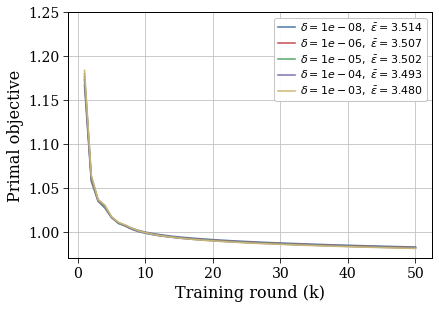

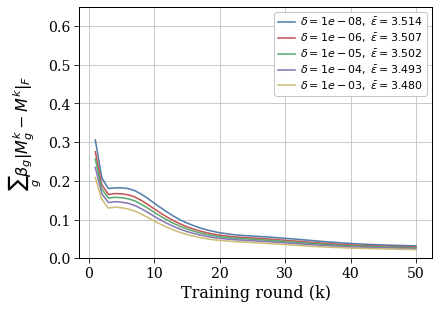

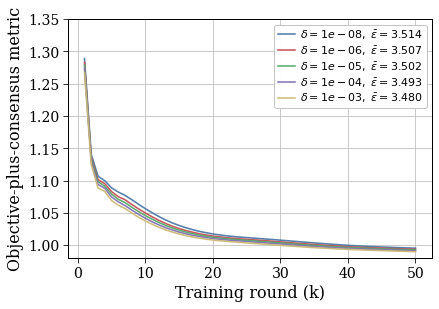

In [43]:
results_csv = run_delta_convergence_experiment(
    delta_list=delta_list,
    eps_dp=eps_dp_fixed,
    seeds=seeds,
    num_rounds=num_rounds,
    train_fn_for_delta=train_dp_dro_csv_for_convergence   # <-- this must match
)

plot_delta_convergence(
    results_csv,
    metric_key="primal_obj_mean",
    epsilon =eps_dp_fixed,
    title=r"",
    ylabel="Primal objective",
    skip_first=False,
    y_limits = (0.97, 1.25)
)

plot_delta_convergence(
    results_csv,
    metric_key="consensus_mean",
    epsilon =eps_dp_fixed, 
    title=r"",
    ylabel=r"$\sum_g \beta_g \|M_g^k - M^k\|_F$",
    skip_first=False,
    y_limits = (0, 0.65)
)
plot_delta_convergence(
    results_csv,
    metric_key="combined_mean",
    epsilon=eps_dp_fixed,  # fixed epsilon for this figure
    title="",
    ylabel=r"Objective-plus-consensus metric",
    skip_first=False,
    y_limits=(0.98, 1.35),
)

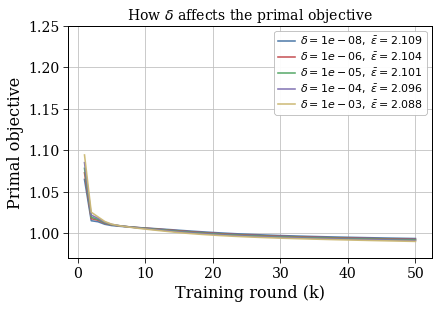

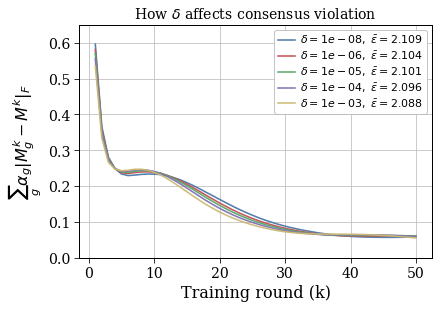

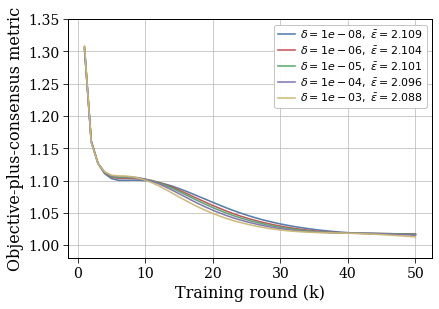

In [33]:
plot_delta_convergence(
    results_csv,
    metric_key="primal_obj_mean",
    epsilon =eps_dp_fixed,
    title=r"How $\delta$ affects the primal objective",
    ylabel="Primal objective",
    skip_first=False,
    y_limits = (0.97, 1.25)
)

plot_delta_convergence(
    results_csv,
    metric_key="consensus_mean",
    epsilon =eps_dp_fixed, 
    title=r"How $\delta$ affects consensus violation",
    ylabel=r"$\sum_g \alpha_g \|M_g^k - M^k\|_F$",
    skip_first=False,
    y_limits = (0, 0.65)
)
plot_delta_convergence(
    results_csv,
    metric_key="combined_mean",
    epsilon=eps_dp_fixed,  # fixed epsilon for this figure
    title="",
    ylabel=r"Objective-plus-consensus metric",
    skip_first=False,
    y_limits=(0.98, 1.35),
) #0.3